# **IMPORTANCIA DE LAS VARIABLES**

In [4]:
import os
import numpy as np
import pandas as pd

from pygam import LogisticGAM, s, f
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score,
    balanced_accuracy_score, average_precision_score, roc_auc_score
)

FEATURE_NAMES = ["T", "P", "ENSO", "sin_doy", "cos_doy"]

def _proba1(model, X):
    p = model.predict_proba(X)
    p = np.asarray(p)
    # Si viene como (n,2) tomamos clase 1; si viene como (n,) lo usamos tal cual
    if p.ndim == 2:
        return p[:, 1]
    return p

def permutation_importance_auc_drop(model, X_test, y_test, n_perm=100, seed=0):
    """
    Devuelve, por variable, la caída de AUROC al permutarla n_perm veces.
    Usa SOLO X_test/y_test (correcto para evitar leakage).

    Retorna:
      drops_mean: dict var -> mean(AUC_base - AUC_perm)
      drops_ci:   dict var -> (p2.5, p97.5)
      drops_all:  dict var -> array de caídas (len=n_perm)
    """
    rng = np.random.default_rng(seed)

    # AUROC base
    
    y_prob_base = _proba1(model, X_test)
    auc_base = roc_auc_score(y_test, y_prob_base)

    drops_all = {}

    for j, name in enumerate(FEATURE_NAMES):
        drops = np.zeros(n_perm, dtype=float)
        for k in range(n_perm):
            Xp = X_test.copy()
            Xp[:, j] = rng.permutation(Xp[:, j])
            y_prob_p = _proba1(model, Xp)
            auc_p = roc_auc_score(y_test, y_prob_p)
            drops[k] = auc_base - auc_p
        drops_all[name] = drops

    drops_mean = {v: float(np.mean(arr)) for v, arr in drops_all.items()}
    drops_ci   = {v: (float(np.quantile(arr, 0.025)), float(np.quantile(arr, 0.975))) for v, arr in drops_all.items()}
    return drops_mean, drops_ci, drops_all


def construir_si_no(seed, 
                    su_si_path, pluv_meta, ruta_series,
                    oni_path,
                    umbral_1d=5, umbral_7d=10, umbral_90d=100):
    rng = np.random.default_rng(seed)


    # Umbrales de lluvia
    UMBRAL_1D  = umbral_1d
    UMBRAL_7D  = umbral_7d
    UMBRAL_90D = umbral_90d

    # ventanas en horas
    H1   = 24
    H7   = 7 * 24
    H90  = 90 * 24

    # -------------------------
    # 1) Cargar inventario de SÍ (Slope Units) y días excluidos ±30
    # -------------------------
    su_si = pd.read_csv(su_si_path, parse_dates=["fecha_hora_evento"])

    # Asegura que tenga si_no=1
    if "si_no" not in su_si.columns:
        su_si["si_no"] = 1
    else:
        su_si.loc[:, "si_no"] = 1  # por si acaso

    # Días a excluir (por día) ±30 alrededor de cada evento SÍ
    excluidas = pd.Index(
        np.unique(
            np.concatenate([
                pd.date_range(d.normalize() - pd.Timedelta(days=30),
                            d.normalize() + pd.Timedelta(days=30),
                            freq="D").date
                for d in su_si["fecha_hora_evento"]
            ])
        )
    )

    # -------------------------
    # 2) Precargar series y armar candidatos (fechas+pluviómetro)
    # -------------------------
    pluvios = pd.read_csv(pluv_meta)

    # Opcional: restringir a pluviómetros que ya usaste en su_si
    # (garantiza asignarles una Slope Unit existente)
    if "Codigo_pluvio_lluvia" in su_si.columns:
        codigos_usable = su_si["Codigo_pluvio_lluvia"].dropna().unique()
        pluvios = pluvios[pluvios["Codigo"].isin(codigos_usable)].copy()

    candidatos = []
    series_acum = {}   # guarda cumsum por código para reutilizar

    rng = np.random.default_rng(seed)

    for _, p in pluvios.iterrows():
        cod = p["Codigo"]
        fn  = f"H_Datos_Procesados_Est_{cod}.csv"
        path = os.path.join(ruta_series, fn)
        if not os.path.exists(path):
            continue

        # Leer serie horaria
        df = pd.read_csv(path, usecols=["Fecha", "P"], parse_dates=["Fecha"])
        serie_h = (df.groupby("Fecha")["P"].sum()
                    .sort_index()
                    .asfreq("H", fill_value=0.0))

        # Cumulada para diferencias rápidas
        cs = serie_h.cumsum().astype(np.float32)
        series_acum[cod] = cs

        idx = cs.index

        # Lluvias acumuladas 1d, 7d, 90d
        ll_1d  = cs - cs.shift(H1)
        ll_7d  = cs - cs.shift(H7)
        ll_90d = cs - cs.shift(H90)

        # Fuera de ventanas excluidas, comparando por DÍA
        fuera_ventanas = ~idx.normalize().isin(excluidas)

        # Candidatos que cumplen umbrales
        mask_ok = (
            fuera_ventanas &
            (ll_1d  >= UMBRAL_1D) &
            (ll_7d  >= UMBRAL_7D) &
            (ll_90d >= UMBRAL_90D)
        )

        fechas_ok = idx[mask_ok]
        if len(fechas_ok):
            # Guardar (timestamp, código) como candidatos
            candidatos.extend([(f, cod) for f in fechas_ok])

    # Quitar duplicados si los hubiera (mismo timestamp+código)
    candidatos = list({(f, c) for (f, c) in candidatos})

    # -------------------------
    # 3) Muestreo: 2× eventos SÍ
    # -------------------------
    n_si = len(su_si)
    n_no_target = 2 * n_si

    if len(candidatos) < n_no_target:
        raise ValueError(
            f"No hay suficientes candidatos que cumplan umbrales y ventanas: "
            f"necesitas {n_no_target}, hay {len(candidatos)}."
        )

    muestras = rng.choice(candidatos, size=n_no_target, replace=False)

    # -------------------------
    # 4) Preparar estructura de columnas: estáticas vs dinámicas
    # -------------------------
    lluvia_cols = [f"{d}d" for d in range(1, 98)]
    dynamic_cols = set(["fecha_hora_evento", "Mes", "DoY", "ONI", "ENSO", "si_no"] + lluvia_cols)

    # columnas estáticas (se copian de una SU real asociada al pluviómetro)
    static_cols = [c for c in su_si.columns if c not in dynamic_cols]

    # -------------------------
    # 5) Construir NO-eventos con acumulados
    # -------------------------
    filas = []

    for fecha, cod in muestras:
        cs = series_acum[cod]

        # Asegurarse de que la fecha esté en el índice (o la anterior)
        if fecha not in cs.index:
            try:
                pos = cs.index.get_loc(fecha, method="pad")
            except KeyError:
                # si no encuentra nada, saltamos este candidato
                continue
        else:
            pos = cs.index.get_loc(fecha)

        # Necesitamos al menos 97 días (97*24 h) hacia atrás
        if pos < 97 * H1:
            continue

        # Acumulados 1–97 días hacia atrás
        vals = cs.iloc[pos] - cs.iloc[pos - np.arange(1, 98) * H1].values

        # Buscar una Slope Unit asociada a este pluviómetro
        if "Codigo_pluvio_lluvia" in su_si.columns:
            su_candidatas = su_si[su_si["Codigo_pluvio_lluvia"] == cod]
        else:
            su_candidatas = su_si

        if su_candidatas.empty:
            # No tenemos SU asociadas a este pluvio, saltamos
            continue

        # Elegimos una SU al azar entre las que usan ese pluviómetro
        base = su_candidatas.sample(1, random_state=rng.integers(0, 10**9)).iloc[0]

        fila = {}

        # Copiamos todas las columnas estáticas desde esa SU
        for col in static_cols:
            fila[col] = base[col]

        # Dinámicas redefinidas
        fila["fecha_hora_evento"] = pd.Timestamp(fecha)
        fila["si_no"] = 0
        fila["Mes"] = fecha.month
        fila["DoY"] = fecha.dayofyear

        # Código de pluviómetro usado para lluvia (si existe en columnas estáticas, lo sobreescribimos)
        if "Codigo_pluvio_lluvia" in su_si.columns:
            fila["Codigo_pluvio_lluvia"] = cod
        else:
            fila["Codigo"] = cod

        # Lluvia 1–97 días
        for d in range(1, 98):
            fila[f"{d}d"] = float(vals[d-1])

        filas.append(fila)

    df_no = pd.DataFrame(filas)

    # Reaplica filtro de umbrales por si alguna fecha quedó al borde de la serie
    df_no = df_no[
        (df_no["1d"]  >= UMBRAL_1D) &
        (df_no["7d"]  >= UMBRAL_7D) &
        (df_no["90d"] >= UMBRAL_90D)   # si usas 90d explícito; si no, ajusta a 91d
    ].copy()

    # Si tras la verificación hay más de lo necesario, recorta aleatoriamente al objetivo
    if len(df_no) > n_no_target:
        df_no = df_no.sample(n=n_no_target, random_state=seed)

    # -------------------------
    # 6) Añadir ONI y ENSO a los NO-eventos
    # -------------------------
    oni_df = pd.read_csv(oni_path, parse_dates=["date"])

    oni_df["date"] = pd.to_datetime(oni_df["date"]).dt.normalize()
    oni_max = oni_df["date"].max()
    oni_min = oni_df["date"].min()
    su_si = su_si[su_si["fecha_hora_evento"].dt.normalize().between(oni_min, oni_max)].copy()

    df_no["date"] = df_no["fecha_hora_evento"].dt.normalize()
    df_no = df_no.merge(
        oni_df[["date", "ONI", "ENSO"]],
        on="date",
        how="left"
    ).drop(columns=["date"])

    df_no = df_no[df_no["fecha_hora_evento"].dt.normalize().between(oni_min, oni_max)].copy()

    # -------------------------
    # 7) Unir SI y NO y guardar
    # -------------------------
    df_si = su_si.copy()

    # Nos aseguramos de que df_no tenga todas las columnas de df_si; las que falten se rellenan con NaN
    for col in df_si.columns:
        if col not in df_no.columns:
            df_no[col] = np.nan

    # Alineamos orden de columnas
    df_no = df_no[df_si.columns]

    df_combined = pd.concat([df_si, df_no], axis=0, ignore_index=True)

    print("Nulos ENSO:", df_combined["ENSO"].isna().sum())
    print("Valores únicos ENSO (muestra):", df_combined["ENSO"].astype(str).str.strip().value_counts().head(20))

    enso_map = {
        "La Niña": 0,
        "Neutro": 1,
        "El Niño": 2,
    }
    df_combined["ENSO_code"] = df_combined["ENSO"].map(enso_map).astype(int)
    print("No mapeados:", df_combined.loc[df_combined["ENSO_code"].isna(), "ENSO"].astype(str).str.strip().value_counts().head(20))
    # Ángulo en radianes
    df_combined["doy_rad"] = 2 * np.pi * (df_combined["DoY"] - 1) / 365.0
    df_combined["sin_doy"] = np.sin(df_combined["doy_rad"])
    df_combined["cos_doy"] = np.cos(df_combined["doy_rad"])
    #df_combined.to_csv(out_path, index=False)

    print(f"Eventos SÍ: {len(df_si)}  |  NO-eventos: {len(df_no)}  |  Total: {len(df_combined)}")
    #print(f"Guardado en: {out_path}")

    return df_combined

def build_TP_dataset(df, t_days=1, p_days=33, max_days=97):
    """
    Construye X, y para una combinación fija de T y P.
    T = R_t
    P = R_{t+p} - R_t
    Donde R_k = lluvia acumulada en k días (columna 'kd').
    """
    total_days = t_days + p_days
    if total_days > max_days:
        raise ValueError(f"T+P = {total_days} > max_days={max_days}")

    col_T = f"{t_days}d"
    col_tot = f"{total_days}d"

    needed_cols = [col_T, col_tot, "Mes", "ONI", "si_no"]
    for c in needed_cols:
        if c not in df.columns:
            raise ValueError(f"Falta la columna {c} en el DataFrame.")

    sub = df.dropna(subset=needed_cols).copy()
    if sub.empty or sub["si_no"].nunique() < 2:
        raise ValueError("No hay datos suficientes o si_no no tiene ambas clases.")

    # T y P
    T_vals = sub[col_T].values
    P_vals = sub[col_tot].values - sub[col_T].values

    # Matriz de predictores: [T, P, Mes, ONI]
    X = np.column_stack([
        T_vals,
        P_vals,
        sub["ENSO_code"].values.astype(int),
        sub["sin_doy"].values.astype(float),
        sub["cos_doy"].values.astype(float)
    ])
    y = sub["si_no"].values.astype(int)

    return X, y

# ---------------------------------------------------
# 2. Configuración del GAM (semi-paramétrico)
# ---------------------------------------------------
# 0: T (corto plazo), 1: P (largo plazo), 2: Mes, 3: ONI
terms = (
    s(0, n_splines=5) +
    s(1, n_splines=5) +
    s(3, n_splines=5) +
    s(4, n_splines=5) +
    f(2)
)

lam_grid = np.logspace(0, 3, 5)  # 1, 3.16, 10, 31.6, 1000 aprox.


def get_best_lambda(X, y):
    """
    Selecciona el mejor lambda para el GAM con un solo split train/val.
    """
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    best_lam = lam_grid[0]
    best_auc = -np.inf

    for lam in lam_grid:
        gam = LogisticGAM(terms, lam=lam)
        gam.fit(X_train, y_train)
        y_prob = gam.predict_proba(X_val)
        auc = roc_auc_score(y_val, y_prob)
        if auc > best_auc:
            best_auc = auc
            best_lam = lam

    return best_lam


def evaluate_models_once(df_mc,
                         t_days=1,
                         p_days=33,
                         test_size=0.30,
                         random_state=42,
                         thr=0.5):
    """
    Entrena y evalúa 3 modelos con un único split estratificado train/test:
    - GAM
    - Regresión Logística
    - Random Forest

    Devuelve 3 dicts (uno por modelo) con AUC, AP(PR-AUC), F1, BAcc y TP/TN/FP/FN.
    """
    X, y = build_TP_dataset(df_mc, t_days=t_days, p_days=p_days)

    # Split único (esto reemplaza la validación cruzada)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )


    def eval_once(y_true, y_prob, thr=0.5):
        y_pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        return {
            "auc":  float(roc_auc_score(y_true, y_prob)),
            "ap":   float(average_precision_score(y_true, y_prob)),  # PR-AUC
            "f1":   float(f1_score(y_true, y_pred, zero_division=0)),
            "bacc": float(balanced_accuracy_score(y_true, y_pred)),
            "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
            "recall": float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0,
            "precision": float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0,
            "pofa": float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
            "HK": float((tp / (tp + fn)) - (fp / (fp + tn))) if (tp + fn) > 0 and (fp + tn) > 0 else 0.0
        }

    def resumen(model_name, metrics):
        return {
            "modelo": model_name,
            "n_obs": int(len(y)),
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "n_folds": 1,
            "threshold": float(thr),
            "auc": metrics["auc"],
            "ap": metrics["ap"],
            "f1": metrics["f1"],
            "bacc": metrics["bacc"],
            "tp": metrics["tp"],
            "tn": metrics["tn"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "recall": metrics["recall"],
            "precision": metrics["precision"],
            "pofa": metrics["pofa"],
            "HK": metrics["HK"],
        }

    # ---------- GAM: best_lam SOLO con TRAIN ----------
    best_lam = get_best_lambda(X_train, y_train)
    print(f"Entrenando GAM (lam={best_lam})...")
    gam = LogisticGAM(terms, lam=best_lam).fit(X_train, y_train)
    y_prob_gam = gam.predict_proba(X_test)
    met_gam = eval_once(y_test, y_prob_gam, thr=thr)

    # ---------- Logit ----------
    print("Entrenando Regresión Logística...")
    logit = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty='l2',
            C=1.0,
            solver='lbfgs',
            max_iter=1000,
            class_weight='balanced'
        )
    )
    logit.fit(X_train, y_train)
    y_prob_logit = logit.predict_proba(X_test)[:, 1]
    met_logit = eval_once(y_test, y_prob_logit, thr=thr)

    # ---------- Random Forest ----------
    print("Entrenando Random Forest...")
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        n_jobs=-1,
        class_weight='balanced',
        random_state=0
    )
    rf.fit(X_train, y_train)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]
    met_rf = eval_once(y_test, y_prob_rf, thr=thr)

    
        # ---------- Importancia por permutación (GAM y Logit) ----------
    drops_gam_mean, drops_gam_ci, _ = permutation_importance_auc_drop(
        gam, X_test, y_test, n_perm=100, seed=123
    )

    drops_logit_mean, drops_logit_ci, _ = permutation_importance_auc_drop(
        logit, X_test, y_test, n_perm=100, seed=123
    )

    importances = []
    for v in FEATURE_NAMES:
        importances.append({
            "modelo": "GAM",
            "variable": v,
            "auc_drop_mean": drops_gam_mean[v],
            "auc_drop_p025": drops_gam_ci[v][0],
            "auc_drop_p975": drops_gam_ci[v][1],
        })
        importances.append({
            "modelo": "Logit",
            "variable": v,
            "auc_drop_mean": drops_logit_mean[v],
            "auc_drop_p025": drops_logit_ci[v][0],
            "auc_drop_p975": drops_logit_ci[v][1],
        })

    return [
        resumen("GAM", met_gam),
        resumen("Logit", met_logit),
        resumen("RandomForest", met_rf),
    ], importances, (gam, logit, rf), (X_test, y_test)



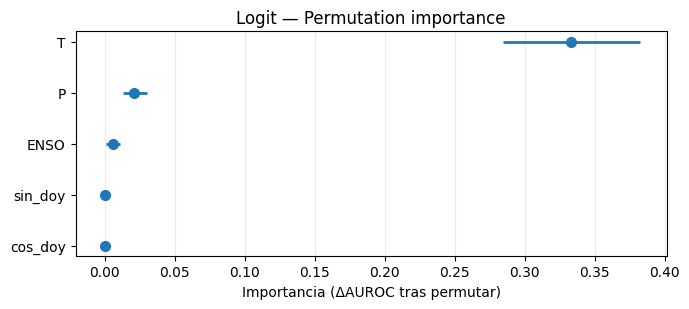

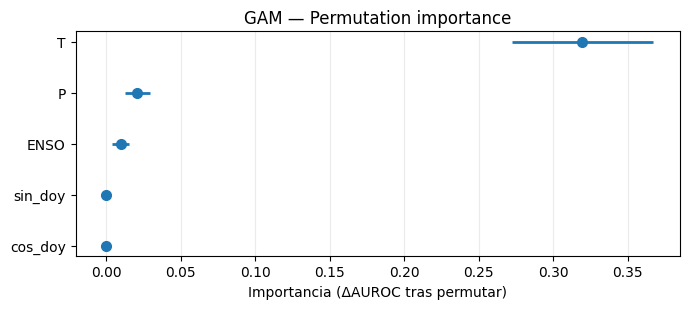

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_importance_dot_ci(imp_df, model_name, title=None):
    d = imp_df[imp_df["modelo"] == model_name].copy()

    # Agrega por MC: si quieres un solo resumen global, usa mediana sobre MC
    g = d.groupby("variable").agg(
        mean_drop=("auc_drop_mean", "median"),
        lo=("auc_drop_p025", "median"),
        hi=("auc_drop_p975", "median"),
    ).reset_index().sort_values("mean_drop")

    y = np.arange(len(g))

    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.hlines(y, g["lo"], g["hi"], linewidth=2)
    ax.plot(g["mean_drop"], y, "o", markersize=7)

    ax.set_yticks(y)
    ax.set_yticklabels(g["variable"])
    ax.set_xlabel("Importancia (ΔAUROC tras permutar)")
    ax.set_title(title or f"Permutation importance — {model_name}")
    ax.grid(True, axis="x", alpha=0.25)
    plt.tight_layout()
    return fig, ax

imp_df = pd.read_csv("/home/oisanchezp/Thesis/data/processed/importancia2026_perm_Logit_GAM.csv")
plot_importance_dot_ci(imp_df, "Logit", "Logit — Permutation importance")
plot_importance_dot_ci(imp_df, "GAM",   "GAM — Permutation importance")
plt.show()


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# =========================
# Config
# =========================
FEATURE_NAMES = ["T", "P", "ENSO", "sin_doy", "cos_doy"]
ENSO_LABELS = {0: "La Niña", 1: "Neutro", 2: "El Niño"}

# =========================
# Helpers generales
# =========================
def make_reference_point(X, strategy="median"):
    if strategy == "median":
        return np.median(X, axis=0)
    if strategy == "mean":
        return np.mean(X, axis=0)
    raise ValueError("strategy debe ser 'median' o 'mean'.")

def proba_clase1(model, X):
    p = np.asarray(model.predict_proba(X))
    return p[:, 1] if p.ndim == 2 else p

def predict_curve(model, x_ref, var_idx, grid):
    Xg = np.tile(x_ref, (len(grid), 1))
    Xg[:, var_idx] = grid
    return proba_clase1(model, Xg)

def doy_curve_from_encoding(model, x_ref, doy_grid=np.arange(1, 366)):
    Xg = np.tile(x_ref, (len(doy_grid), 1))
    doy_rad = 2*np.pi*(doy_grid - 1)/365.0
    Xg[:, FEATURE_NAMES.index("sin_doy")] = np.sin(doy_rad)
    Xg[:, FEATURE_NAMES.index("cos_doy")] = np.cos(doy_rad)
    return doy_grid, proba_clase1(model, Xg)

def enso_effect(model, x_ref, enso_codes=(0, 1, 2)):
    Xg = np.tile(x_ref, (len(enso_codes), 1))
    Xg[:, FEATURE_NAMES.index("ENSO")] = np.array(enso_codes, dtype=float)
    return np.array(enso_codes), proba_clase1(model, Xg)

# =========================
# GAM: pred + intervalos (robusto a versiones)
# =========================
def gam_proba_and_ci(gam, Xg, width=0.95):
    p = np.asarray(gam.predict_proba(Xg)).ravel()

    if hasattr(gam, "prediction_intervals"):
        ci = gam.prediction_intervals(Xg, width=width)
    elif hasattr(gam, "confidence_intervals"):
        ci = gam.confidence_intervals(Xg, width=width)
    else:
        raise AttributeError(
            "Tu pyGAM no tiene prediction_intervals ni confidence_intervals. "
            "Actualiza pygam o hacemos bootstrap."
        )

    lo, hi = ci[:, 0], ci[:, 1]
    return p, lo, hi

def gam_curve_ci(gam, x_ref, var_idx, grid, width=0.95):
    Xg = np.tile(x_ref, (len(grid), 1))
    Xg[:, var_idx] = grid
    return gam_proba_and_ci(gam, Xg, width=width)

def gam_doy_curve_ci(gam, x_ref, doy_grid=np.arange(1, 366), width=0.95):
    Xg = np.tile(x_ref, (len(doy_grid), 1))
    doy_rad = 2*np.pi*(doy_grid - 1)/365.0
    Xg[:, FEATURE_NAMES.index("sin_doy")] = np.sin(doy_rad)
    Xg[:, FEATURE_NAMES.index("cos_doy")] = np.cos(doy_rad)
    p, lo, hi = gam_proba_and_ci(gam, Xg, width=width)
    return doy_grid, p, lo, hi

def gam_enso_ci(gam, x_ref, enso_codes=(0, 1, 2), width=0.95):
    Xg = np.tile(x_ref, (len(enso_codes), 1))
    Xg[:, FEATURE_NAMES.index("ENSO")] = np.array(enso_codes, dtype=float)
    p, lo, hi = gam_proba_and_ci(gam, Xg, width=width)
    return np.array(enso_codes), p, lo, hi

# =========================
# Plots: Logit / RF / etc (curvas simples)
# =========================
def plot_partial_effects_basic(model, X_test, title="Partial effects", n_grid=200):
    x_ref = make_reference_point(X_test, "median")

    T_grid = np.linspace(np.percentile(X_test[:, 0], 1), np.percentile(X_test[:, 0], 99), n_grid)
    P_grid = np.linspace(np.percentile(X_test[:, 1], 1), np.percentile(X_test[:, 1], 99), n_grid)

    pT = predict_curve(model, x_ref, 0, T_grid)
    pP = predict_curve(model, x_ref, 1, P_grid)
    doy_g, pD = doy_curve_from_encoding(model, x_ref)
    enso_codes, pE = enso_effect(model, x_ref)

    fig, axs = plt.subplots(2, 2, figsize=(10, 6))

    axs[0, 0].plot(T_grid, pT)
    axs[0, 0].set_xlabel("T (lluvia corto plazo)")
    axs[0, 0].set_ylabel("Probabilidad predicha")

    axs[0, 1].plot(P_grid, pP)
    axs[0, 1].set_xlabel("P (lluvia largo plazo)")
    axs[0, 1].set_ylabel("Probabilidad predicha")

    axs[1, 0].plot(doy_g, pD)
    axs[1, 0].set_xlabel("Día del año (DoY)")
    axs[1, 0].set_ylabel("Probabilidad predicha")

    axs[1, 1].plot(enso_codes, pE, marker = "o", linestyle="none")
    axs[1, 1].set_xticks(enso_codes)
    axs[1, 1].set_xticklabels([ENSO_LABELS[int(c)] for c in enso_codes])
    axs[1, 1].set_xlabel("ENSO")
    axs[1, 1].set_ylabel("Probabilidad predicha")

    for ax in axs.ravel():
        ax.grid(True, alpha=0.25)

    fig.suptitle(title)
    plt.tight_layout()
    return fig, axs

def plot_partial_effects_gam_ci(gam, X_test, title="GAM — efectos parciales", n_grid=200, width=0.95):
    x_ref = make_reference_point(X_test, "median")

    T_grid = np.linspace(np.percentile(X_test[:, 0], 1), np.percentile(X_test[:, 0], 99), n_grid)
    P_grid = np.linspace(np.percentile(X_test[:, 1], 1), np.percentile(X_test[:, 1], 99), n_grid)

    pT, loT, hiT = gam_curve_ci(gam, x_ref, var_idx=0, grid=T_grid, width=width)
    pP, loP, hiP = gam_curve_ci(gam, x_ref, var_idx=1, grid=P_grid, width=width)

    doy_g, pD, loD, hiD = gam_doy_curve_ci(gam, x_ref, width=width)
    enso_codes, pE, loE, hiE = gam_enso_ci(gam, x_ref, width=width)

    fig, axs = plt.subplots(2, 2, figsize=(10, 6))

    axs[0, 0].plot(T_grid, pT)
    axs[0, 0].fill_between(T_grid, loT, hiT, alpha=0.2)
    axs[0, 0].set_xlabel("T (lluvia corto plazo)")
    axs[0, 0].set_ylabel("Probabilidad predicha")

    axs[0, 1].plot(P_grid, pP)
    axs[0, 1].fill_between(P_grid, loP, hiP, alpha=0.2)
    axs[0, 1].set_xlabel("P (lluvia largo plazo)")
    axs[0, 1].set_ylabel("Probabilidad predicha")

    axs[1, 0].plot(doy_g, pD)
    axs[1, 0].fill_between(doy_g, loD, hiD, alpha=0.2)
    axs[1, 0].set_xlabel("Día del año (DoY)")
    axs[1, 0].set_ylabel("Probabilidad predicha")

    yerr = np.vstack([pE - loE, hiE - pE])
    axs[1, 1].errorbar(enso_codes, pE, yerr=yerr, fmt="o", capsize=4, linestyle="none")
    axs[1, 1].set_xticks(enso_codes)
    axs[1, 1].set_xticklabels([ENSO_LABELS[int(c)] for c in enso_codes])
    axs[1, 1].set_xlabel("ENSO")
    axs[1, 1].set_ylabel("Probabilidad predicha")

    for ax in axs.ravel():
        ax.grid(True, alpha=0.25)

    fig.suptitle(title)
    plt.tight_layout()
    return fig, axs

In [7]:

# =========================
# SHAP: RF
# =========================

FEATURE_NAMES = ["T", "P", "ENSO", "sin_doy", "cos_doy"]

def shap_summary_rf(rf_model, X_test, feature_names=FEATURE_NAMES):
    X_df = pd.DataFrame(X_test, columns=feature_names)
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_df)
    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(shap_vals, X_df, plot_type="dot", show=True)
    return shap_vals, X_df

def shap_dependence(shap_vals, X_df, feature, color_by=None):
    shap.dependence_plot(
        feature, shap_vals, X_df,
        interaction_index=color_by,
        show=True
    )

def shap_grouped_importance(shap_vals, X_df):
    imp = np.abs(shap_vals).mean(axis=0)
    imp_s = pd.Series(imp, index=X_df.columns)

    grouped = pd.Series({
        "T": imp_s.get("T", 0.0),
        "P": imp_s.get("P", 0.0),
        "ENSO": imp_s.get("ENSO", 0.0),
        "DoY": imp_s.get("sin_doy", 0.0) + imp_s.get("cos_doy", 0.0),
    }).sort_values(ascending=False)

    return imp_s.sort_values(ascending=False), grouped

In [8]:
import json
import pandas as pd
import shap

# 1) cargar selección de corrida representativa
json_path = "/home/oisanchezp/Thesis/data/processed/seleccion_corrida_mediana_paquete_a.json"
with open(json_path, "r") as f:
    sel = json.load(f)

su_si_path  = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.csv"
pluv_meta   = "/home/oisanchezp/Thesis/data/metadata/pluviometros_metadatos_20250506.csv"
ruta_series = "/mnt/investigacion/geotecnia/Pluvios_horarios/Pluvios_horarios_completos/"
oni_path    = "/home/oisanchezp/Thesis/data/metadata/oni_diario_2010_2025.csv"


# 2) reconstruir dataset de esa corrida (misma seed)
df_star = construir_si_no(
    seed=sel["seed_star"],
    su_si_path=su_si_path,
    pluv_meta=pluv_meta,
    ruta_series=ruta_series,
    oni_path=oni_path,
    umbral_1d=5, umbral_7d=10, umbral_90d=100
)

# 3) entrenar modelos y obtener X_test
resultados_star, imps_star, models_star, test_star = evaluate_models_once(
    df_star,
    t_days=sel["t_days"],
    p_days=sel["p_days"],
    random_state=sel["random_state_split"],
    thr=sel["threshold"]
)

(gam, logit, rf) = models_star
(X_test, y_test) = test_star




Nulos ENSO: 0
Valores únicos ENSO (muestra): ENSO
Neutro     571
La Niña    527
El Niño    246
Name: count, dtype: int64
No mapeados: Series([], Name: count, dtype: int64)
Eventos SÍ: 458  |  NO-eventos: 886  |  Total: 1344
Entrenando GAM (lam=1.0)...
Entrenando Regresión Logística...
Entrenando Random Forest...


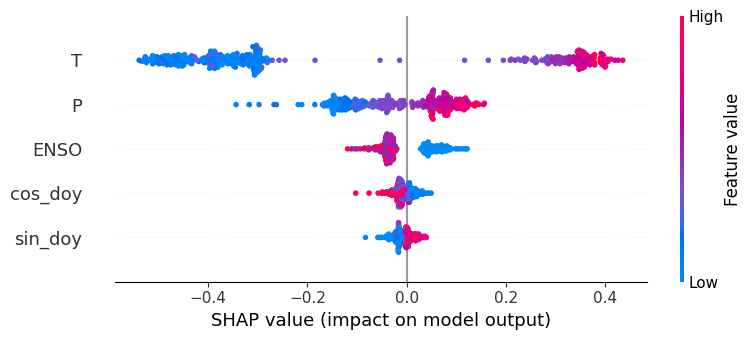

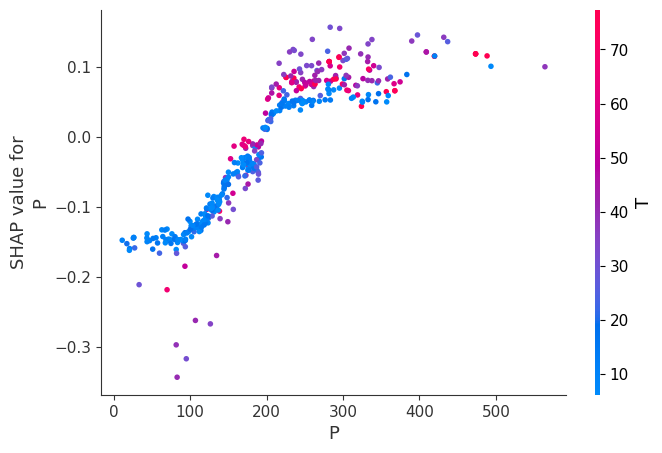

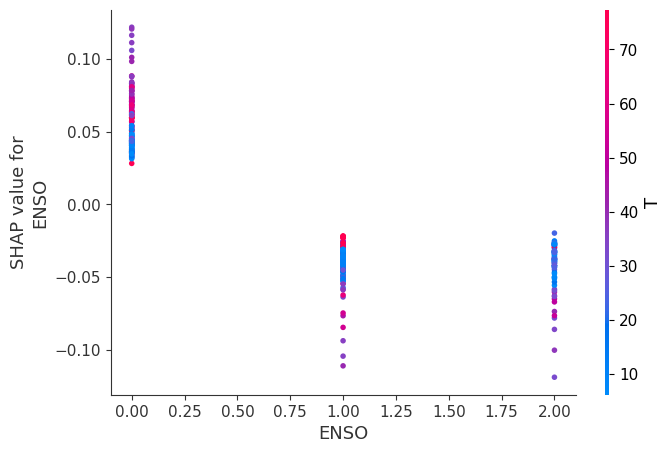

T       0.365533
P       0.087248
ENSO    0.047020
DoY     0.029049
dtype: float64


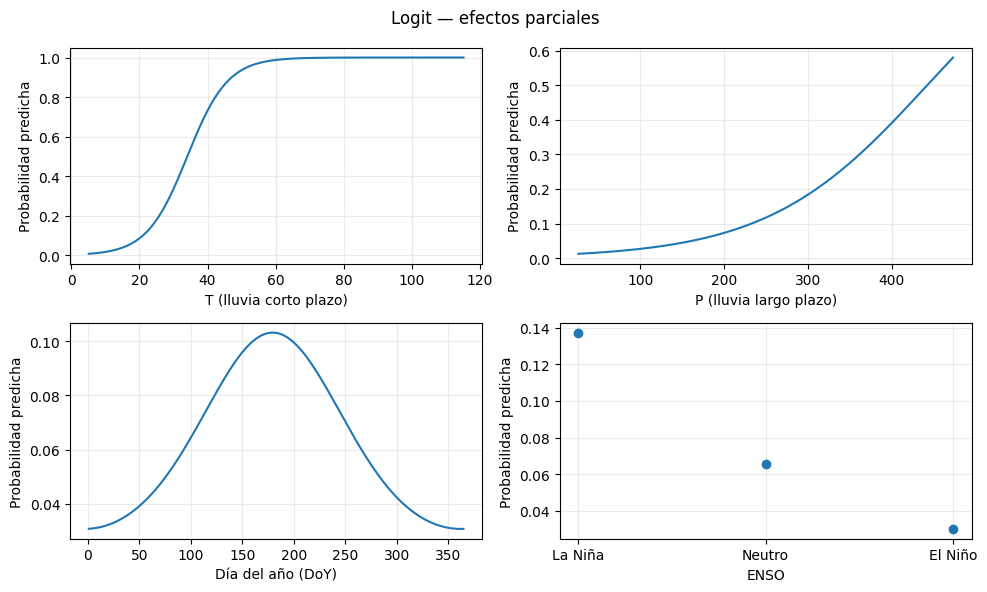

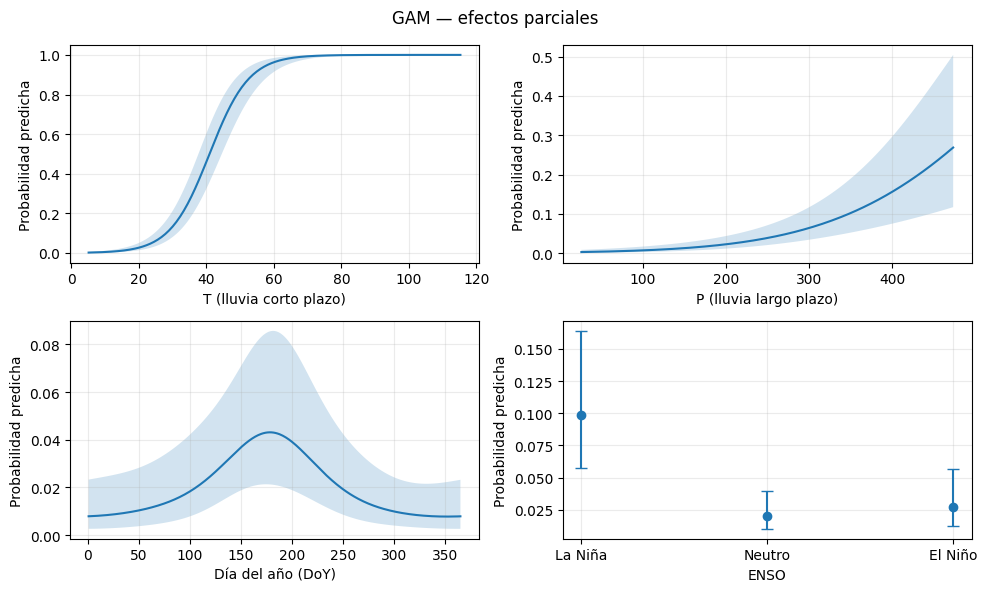

In [12]:
# SHAP (RF)
shap_vals, X_df = shap_summary_rf(rf, X_test)
shap_dependence(shap_vals, X_df, feature="P", color_by="T")
shap_dependence(shap_vals, X_df, feature="ENSO", color_by="T")

# Importancia agrupada DoY = sin+cos
imp_raw, imp_grouped = shap_grouped_importance(shap_vals, X_df)
print(imp_grouped)

# Curvas
plot_partial_effects_basic(logit, X_test, title="Logit — efectos parciales")
plot_partial_effects_gam_ci(gam, X_test, title="GAM — efectos parciales", width=0.95)
plt.show()


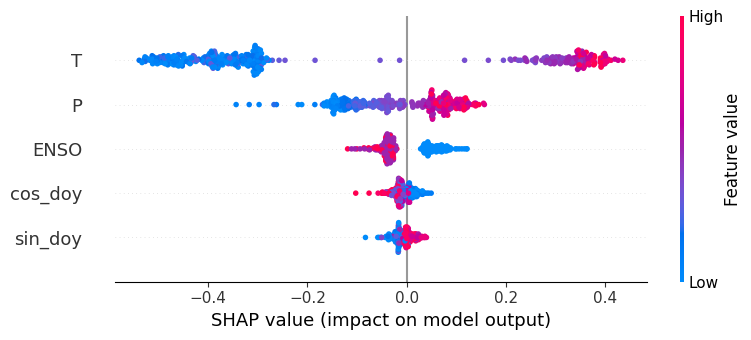

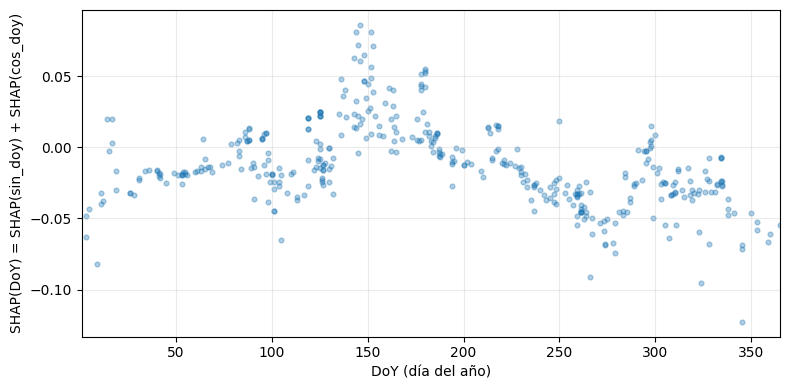

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def doy_from_sin_cos(sin_vals, cos_vals):
    ang = np.arctan2(sin_vals, cos_vals)      # [-pi, pi]
    ang = (ang + 2*np.pi) % (2*np.pi)         # [0, 2pi)
    doy = 1 + (ang / (2*np.pi)) * 365.0
    return doy

def shap_doy_dependence(shap_vals, X_df, alpha=0.35, s=12):
    # DoY en [1,365]
    doy = doy_from_sin_cos(X_df["sin_doy"].values, X_df["cos_doy"].values)

    # “Efecto DoY” = contribución conjunta sin+cos
    shap_doy = shap_vals[:, X_df.columns.get_loc("sin_doy")] + shap_vals[:, X_df.columns.get_loc("cos_doy")]

    # ordenar para que se vea bonito
    order = np.argsort(doy)

    plt.figure(figsize=(8, 4))
    plt.scatter(doy[order], shap_doy[order], alpha=alpha, s=s)
    plt.xlim(1, 365)
    plt.xlabel("DoY (día del año)")
    plt.ylabel("SHAP(DoY) = SHAP(sin_doy) + SHAP(cos_doy)")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

# uso:
shap_vals, X_df = shap_summary_rf(rf, X_test)
shap_doy_dependence(shap_vals, X_df)


## TAREAS DE EFECTO PARCIALES

- Arreglar 